In [160]:
%matplotlib inline

import random
import torch
from matplotlib_inline import backend_inline
import matplotlib.pyplot as plt

In [161]:
# 使用 w = [2, -3.4], b = 4.2 和噪声eps噪声项生成数据
# eps 服从均值为0的正态分布

def synthetic_data(w, b, num_example):
    """生成y = xw + b + noise"""
    X = torch.normal(0, 1, (num_example, len(w)))
    y = torch.matmul(X, w) + b
    y += torch.normal(0, 0.01, y.shape)
    return X, y.reshape((-1, 1))

In [162]:
true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)
features, labels

(tensor([[-0.7504,  0.2494],
         [-0.7552, -0.7240],
         [ 0.2473, -0.0975],
         ...,
         [-1.5123,  0.4051],
         [-0.3111,  0.0626],
         [ 0.3559, -0.9135]]),
 tensor([[ 1.8536e+00],
         [ 5.1481e+00],
         [ 5.0176e+00],
         [-1.7909e+00],
         [ 4.8122e+00],
         [-2.0658e+00],
         [-2.9076e+00],
         [-8.2395e-01],
         [ 9.1800e+00],
         [ 3.3456e+00],
         [ 1.0529e+01],
         [ 3.7982e+00],
         [ 5.5789e+00],
         [ 6.4215e+00],
         [ 4.1564e+00],
         [-1.8266e+00],
         [ 6.3308e+00],
         [-2.0908e+00],
         [-5.9199e+00],
         [ 4.4359e+00],
         [-3.5001e+00],
         [-7.7720e-01],
         [ 8.6668e+00],
         [ 8.7015e-01],
         [ 5.5952e+00],
         [ 3.3670e+00],
         [-1.6920e+00],
         [-9.5486e-02],
         [ 7.2314e+00],
         [ 1.7544e+00],
         [ 1.0980e+01],
         [ 5.4080e+00],
         [-1.5448e+00],
         [ 1.6012e

In [163]:
print(f"features: {features[0]}, label: {labels[0]}")
print(features.shape, labels.shape)

features: tensor([-0.7504,  0.2494]), label: tensor([1.8536])
torch.Size([1000, 2]) torch.Size([1000, 1])


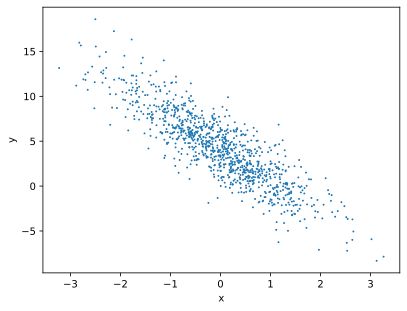

In [164]:
# 绘制 features与labels之间的关系
fig, ax = plt.subplots()
backend_inline.set_matplotlib_formats('svg')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.scatter(features[:, (1)].detach().numpy(), labels.detach().numpy(), s=1)
plt.show()


In [ ]:
# 读取数据集
def data_iter(batch_size, features, labels):
    """
    yeild 关键词返回一个generator, 
    它是一个generator对象，可以用next(gen_obj)
    访问下一批数据, 或者用for循环遍历访问
    """
    num_examples = len(features)
    indices = list(range(num_examples)) # index的复数
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [169]:
for X, y in data_iter(10, features, labels):
    print(X, y, sep='\n')

tensor([[-0.6160,  2.6361],
        [-0.3968, -0.5812],
        [ 1.9051, -1.9209],
        [ 0.8926, -0.1784],
        [ 0.1005,  0.9946],
        [-0.3953, -0.3607],
        [ 0.3896, -1.6695],
        [ 1.7115, -0.0299],
        [-1.5739,  1.2185],
        [ 1.2932,  0.1405]])
tensor([[-5.9872],
        [ 5.3860],
        [14.5227],
        [ 6.5848],
        [ 1.0298],
        [ 4.6378],
        [10.6745],
        [ 7.7273],
        [-3.0947],
        [ 6.3270]])
tensor([[ 0.1692,  0.0877],
        [-0.5691,  0.5586],
        [-2.2873, -1.1072],
        [ 0.8371,  0.5486],
        [-0.8749,  0.4942],
        [ 0.2513,  1.3006],
        [-0.5868, -1.9452],
        [ 0.0030,  0.8840],
        [-0.8467, -0.1576],
        [-0.3966, -1.1242]])
tensor([[4.2479],
        [1.1710],
        [3.3944],
        [4.0122],
        [0.7824],
        [0.2808],
        [9.6410],
        [1.1965],
        [3.0333],
        [7.2314]])
tensor([[-0.0069,  0.3188],
        [-0.8616,  0.4979],
        [ 